## "Há evidências de que filmes de ação lançados a partir de 2005 apresentam desempenho comercial inferior aos lançados anteriormente?"

A partir desse questionamento, podemos olhar mais especificamente para três dados(Colunas) em especifico: 

**Year**(O ano em que foi lançado o filme) <br> <br>
**World Wide Sales (in $)** (Que é o montante total que o filme lucrou mundialmente). <br> <br>
**Genre** (Que é o genero do filme em questão)

## Hipótese

**Conforme o passar dos anos, os filmes de ação diminuiram com o lucro mundial. Assim, indicando uma proporção invertidade do lucro em relação ao ano de lançamento**

In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)
df.head()


c:\Users\Thiago Medeiros\Desktop\TrabalhoEstatistica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Thiago Medeiros\AppData\Local\Temp\ipykernel_11596\2974614052.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


,Unnamed: 0,Title,Movie Info,Year,Distributor,Budget (in $),Domestic Opening (in $),Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Release Date,Genre,Running Time,License
0,0,Avatar,A paraplegic Marine dispatched to the moon Pan...,2009,Twentieth Century Fox,237000000,77025481,785221649,2138484377,2923706026,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
1,1,Avengers: Endgame,After the devastating events of Avengers: Infi...,2019,Walt Disney Studios Motion Pictures,356000000,357115007,858373000,1941066100,2799439100,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,2,Avatar: The Way of Water,Jake Sully lives with his newfound family form...,2022,20th Century Studios,December 14 2022 (EMEA APAC),134100226,684075767,1636174514,2320250281,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
3,3,Titanic,A seventeen-year-old aristocrat falls in love ...,1997,Paramount Pictures,200000000,28638131,674292608,1590450697,2264743305,19-Dec-97,"['Drama', 'Romance']",3 hr 14 min,PG-13
4,4,Star Wars: Episode VII - The Force Awakens,"As a new threat to the galaxy rises, Rey, a de...",2015,Walt Disney Studios Motion Pictures,245000000,247966675,936662225,1134647993,2071310218,16-Dec-15,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13


## Pré-processamento de dados e entendendo a estrutura geral
Para garantir a qualidade e a confiabilidade das nossas análises, o primeiro passo será realizar uma etapa rigorosa de limpeza e validação da base de dados. As operações que faremos incluem:

Filtragem temporal e de domínio: Manteremos apenas os registros referentes a anos superiores a 1900 e garantiremos que os valores de interesse sejam estritamente maiores que zero, descartando previamente qualquer anomalia negativa.

Garantia de integridade: Faremos a verificação e a remoção de dados duplicados, confirmaremos a inexistência de valores nulos e trataremos quaisquer dados inconsistentes (garantindo que os tipos e formatos estejam coerentes).

Limitando o escopo: iremos limitar o escopo apenas para as colunas que nos importam para a analise, sendo elas: Title (titulo do filme), Year (ano de lançamento), World Wide Sales (vendas no mundo) e Genre (genero de ação).

In [2]:
print(df.info())
print('Quantidade de linhas duplicadas:', df.duplicated().sum())
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Unnamed: 0                  1000 non-null   int64
 1   Title                       1000 non-null   str  
 2   Movie Info                  1000 non-null   str  
 3   Year                        1000 non-null   int64
 4   Distributor                 999 non-null    str  
 5   Budget (in $)               1000 non-null   str  
 6   Domestic Opening (in $)     1000 non-null   str  
 7   Domestic Sales (in $)       1000 non-null   int64
 8   International Sales (in $)  1000 non-null   int64
 9   World Wide Sales (in $)     1000 non-null   int64
 10  Release Date                1000 non-null   str  
 11  Genre                       1000 non-null   str  
 12  Running Time                1000 non-null   str  
 13  License                     943 non-null    str  
dtypes: int64(5), str(9)


,Unnamed: 0,Title,Movie Info,Year,Distributor,Budget (in $),Domestic Opening (in $),Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Release Date,Genre,Running Time,License
count,1000.000000,1000,1000,1000.000000,999,1000,1000,1.000000e+03,1.000000e+03,1.000000e+03,1000,1000,1000,943
unique,NaN,988,999,NaN,71,361,997,NaN,NaN,NaN,713,275,100,4
top,NaN,The Lion King,A kind-hearted street urchin and a power-hungr...,NaN,Warner Bros.,150000000,2 hr 2 min,NaN,NaN,NaN,28-Jun-07,"['Action', 'Adventure', 'Sci-Fi']",1 hr 46 min,PG-13
freq,NaN,2,2,NaN,166,44,2,NaN,NaN,NaN,5,70,27,486
mean,499.500000,NaN,NaN,2008.181000,NaN,NaN,NaN,1.646405e+08,2.640890e+08,4.228430e+08,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,10.585854,NaN,NaN,NaN,1.197541e+08,2.133847e+08,3.054844e+08,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,1937.000000,NaN,NaN,NaN,6.752000e+03,2.450000e+07,1.799689e+08,NaN,NaN,NaN,NaN
25%,249.750000,NaN,NaN,2002.000000,NaN,NaN,NaN,9.572506e+07,1.321190e+08,2.272899e+08,NaN,NaN,NaN,NaN
50%,499.500000,NaN,NaN,2010.000000,NaN,NaN,NaN,1.349169e+08,1.941077e+08,3.197148e+08,NaN,NaN,NaN,NaN
75%,749.250000,NaN,NaN,2016.000000,NaN,NaN,NaN,1.983993e+08,3.188993e+08,4.852363e+08,NaN,NaN,NaN,NaN


In [3]:
df_action = df[
    df["Genre"].apply(lambda generos: "Action" in generos)
    & (df["Year"] >= 1900)
    & (df["World Wide Sales (in $)"] >= 0)
].copy()

df_action[["Title", "Year", "Genre", "World Wide Sales (in $)"]]

,Title,Year,Genre,World Wide Sales (in $)
0,Avatar,2009,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2923706026
1,Avengers: Endgame,2019,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2799439100
2,Avatar: The Way of Water,2022,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2320250281
4,Star Wars: Episode VII - The Force Awakens,2015,"['Action', 'Adventure', 'Sci-Fi']",2071310218
5,Avengers: Infinity War,2018,"['Action', 'Adventure', 'Sci-Fi']",2052415039
...,...,...,...,...
991,Hot Shots!,1991,"['Action', 'Comedy']",181096164
993,Kill Bill: Vol. 1,2003,"['Action', 'Crime', 'Thriller']",180906076
994,The Scorpion King,2002,"['Action', 'Adventure', 'Fantasy']",180630907
998,Deja Vu,2006,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",180557550


Após a execução da limpeza, filtragem e definição de escopo, consolidamos o dataframe final (df_action) e concluímos que:

Base Limpa e Consistente: Obtivemos 508 registros válidos, sem dados duplicados ou valores nulos nas colunas de escopo (Title, Year, Genre e World Wide Sales).

Regras de Negócio Atendidas: A base agora reflete apenas filmes de Ação ("Action"), lançados a partir de 1900 e com faturamento positivo, removendo anomalias.

## Conclusão do Pré-processamento e Próximos Passos
Após a aplicação dos filtros, chegamos a um dataframe limpo e íntegro com 508 registros de filmes de ação. No entanto, ao observarmos os dados resultantes, fica evidente um desafio analítico: estamos lidando com variáveis que possuem escalas de grandeza drasticamente diferentes.

Enquanto a coluna Year transita na casa dos milhares (ex: 2009, 2019), a coluna World Wide Sales opera na casa das centenas de milhões e bilhões de dólares (ex: o faturamento de Avatar ultrapassa 2.9 bilhões). Essa disparidade pode distorcer visualizações gráfica, por isso, a normalização (ou padronização) dos dados será uma etapa indispensável.

Porém, antes de aplicar qualquer transformação matemática, precisamos realizar uma Análise Exploratória de Dados (EDA) para entender o comportamento real dessas variáveis. Nossas próximas perguntas a serem respondidas graficamente são:

Como está a distribuição dos valores de faturamento?

A base possui muitos outliers (sucessos de bilheteria muito fora da curva que puxam a média para cima)?

Existe alguma tendência de aumento de bilheteria ao longo dos anos?

Entender o formato e a dispersão dos nossos dados será o guia fundamental para definirmos qual método de normalização utilizaremos na sequência.

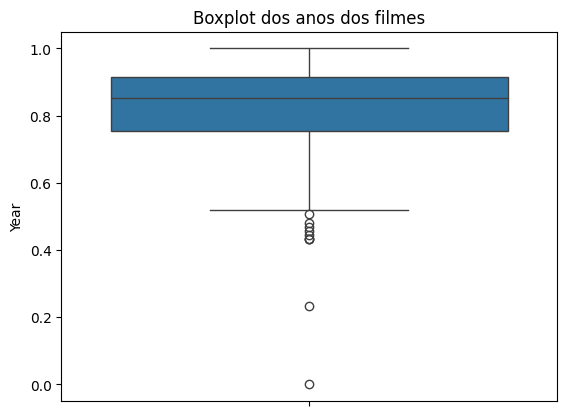

Mediana dos anos: 2011.0
Média dos anos: 2008.6948818897638
Q1: 2003.0
Q2: 2011.0
Q3: 2016.0
Q4: 2023.0
Amplitude: 81 anos
Variância: 107.48660097221577
Desvio padrão: 10.367574498030663



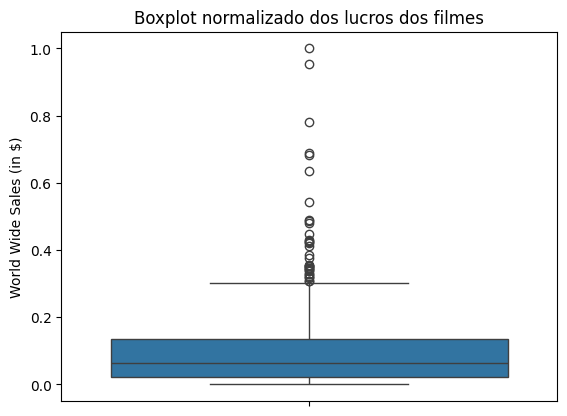

Mediana das vendas mundiais: 351015776.0
Média das vendas mundiais: 465332656.242126
Q1: 240563205.75
Q2: 351015776.0
Q3: 552907125.25
Q4: 2923706026.0
Amplitude: 2743737153
Variância: 1.2017015843694398e+17
Desvio padrão: 346655677.0585821


In [4]:
df_normalizado = df_action.copy()

df_normalizado["Year"] = (
    (df_action["Year"] - df_action["Year"].min()) /
    (df_action["Year"].max() - df_action["Year"].min())
)

df_normalizado["World Wide Sales (in $)"] = (
    (df_action["World Wide Sales (in $)"] - df_action["World Wide Sales (in $)"].min()) /
    (df_action["World Wide Sales (in $)"].max() - df_action["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_action['Year'].median()}\nMédia dos anos: {df_action['Year'].mean()}")
print(f"Q1: {df_action['Year'].quantile(.25)}\nQ2: {df_action['Year'].quantile(.50)}\nQ3: {df_action['Year'].quantile(.75)}\nQ4: {df_action['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action['Year'].max() - df_action['Year'].min()} anos")
print(f"Variância: {df_action['Year'].var()}")
print(f"Desvio padrão: {df_action['Year'].std()}")
print()

sns.boxplot(y=df_normalizado['World Wide Sales (in $)'])
plt.title("Boxplot normalizado dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action['World Wide Sales (in $)'].max() - df_action['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action['World Wide Sales (in $)'].std()}")

## Análise Exploratória: Visão Global
### Ano de Lançamento
A distribuição dos anos apresenta uma assimetria à esquerda. Embora a base tenha uma amplitude histórica considerável de 81 anos (com os dados mais antigos puxando a cauda do boxplot para baixo), há uma forte concentração de filmes no período recente. A análise dos quartis revela que 50% de todos os filmes da base foram lançados em uma janela de apenas 13 anos (entre o Q1 em 2003 e o Q3 em 2016). O desvio padrão relativamente pequeno (aprox. 10 anos) em relação à amplitude total reforça essa alta densidade nas últimas duas décadas.

### Vendas Mundiais (World Wide Sales)
O faturamento global apresenta o comportamento oposto: uma forte assimetria à direita (positiva). A média de arrecadação (aprox. 465 milhões) é significativamente maior que a mediana (aprox. 351 milhões). Como a mediana representa o valor que divide os dados exatamente ao meio, essa diferença indica que a grande maioria dos filmes tem lucros mais modestos, mas a presença de diversos e extremos outliers superiores (os "mega blockbusters") puxa o valor da média drasticamente para cima. O desvio padrão altíssimo comprova a extrema volatilidade e dispersão do mercado de cinema.

### Conclusão Conjunta e Próxima Etapa
A análise inicial revela que o mercado de filmes de ação é altamente desigual: poucos títulos concentram arrecadações bilionárias, distorcendo a média do conjunto. Além disso, a produção e os registros estão massivamente concentrados nos anos 2000 em diante.

Analisar esse bloco de dados como uma coisa só pode gerar distorções, pois os gigantescos sucessos de bilheteria recentes podem mascarar o comportamento financeiro dos filmes mais antigos. Portanto, para responder à nossa pergunta de pesquisa com precisão e entender se o mercado realmente inflou ou mudou de comportamento, a próxima etapa metodológica obrigatória é segmentar o dataframe e comparar separadamente os filmes lançados antes de 2005 com aqueles lançados a partir de 2005.

#### Devemos dividir os dados em dois quadrantes:<br><br>

##### Pré 2005<br><br>
##### Pós 2005<br><br>

In [5]:
df_action_pre = df_action[
    df_action['Year'] < 2005
    ]

df_action_pos = df_action[
    df_action['Year'] >= 2005
    ]

Vamos usar também a correlação de Spearman para procurar uma proporção entre as medidas. Usaremos Sperman ao inves de Pearson devido a grande quantidade de outliers vista no macro.

In [20]:
coef_spearman, p_spearman = spearmanr(df_action_pre["Year"], df_action_pre["World Wide Sales (in $)"])
print("Spearman pre-2005:", coef_spearman)
coef_spearman, p_spearman = spearmanr(df_action_pos["Year"], df_action_pos["World Wide Sales (in $)"])
print("Spearman pos-2005:", coef_spearman)

Spearman pre-2005: 0.04570803241560657
Spearman pos-2005: 0.09356159427326777


# Pré-2005

Filmes de ação antes de 2005: 152


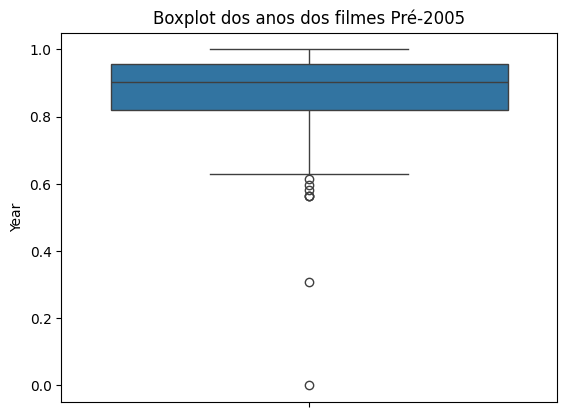

Mediana dos anos: 1998.0
Média dos anos: 1995.8026315789473
Q1: 1992.75
Q2: 1998.0
Q3: 2001.25
Q4: 2004.0
Amplitude: 62 anos
Variância: 70.53032415475775
Desvio padrão: 8.398233394872861



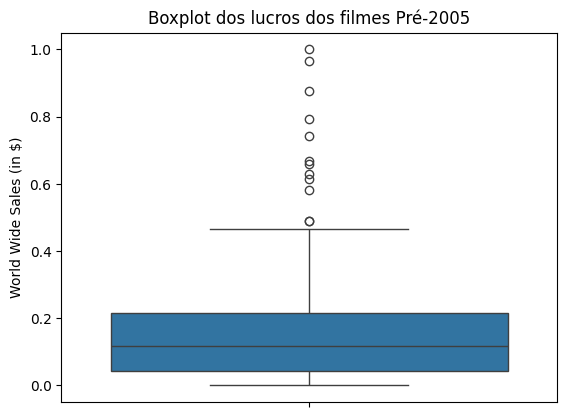

Mediana das vendas mundiais: 293587398.5
Média das vendas mundiais: 348617211.30921054
Q1: 222569299.25
Q2: 293587398.5
Q3: 390067955.25
Q4: 1147633833.0
Amplitude: 967002926
Variância: 3.510390408925029e+16
Desvio padrão: 187360358.90564016


In [7]:
df_normalizado_pre = df_action_pre.copy()
print("Filmes de ação antes de 2005:", len(df_action_pre))

df_normalizado_pre["Year"] = (
    (df_action_pre["Year"] - df_action_pre["Year"].min()) /
    (df_action_pre["Year"].max() - df_action_pre["Year"].min())
)

df_normalizado_pre["World Wide Sales (in $)"] = (
    (df_action_pre["World Wide Sales (in $)"] - df_action_pre["World Wide Sales (in $)"].min()) /
    (df_action_pre["World Wide Sales (in $)"].max() - df_action_pre["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pre['Year'])
plt.title("Boxplot dos anos dos filmes Pré-2005")
plt.show()

print(f"Mediana dos anos: {df_action_pre['Year'].median()}\nMédia dos anos: {df_action_pre['Year'].mean()}")
print(f"Q1: {df_action_pre['Year'].quantile(.25)}\nQ2: {df_action_pre['Year'].quantile(.50)}\nQ3: {df_action_pre['Year'].quantile(.75)}\nQ4: {df_action_pre['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action_pre['Year'].max() - df_action_pre['Year'].min()} anos")
print(f"Variância: {df_action_pre['Year'].var()}")
print(f"Desvio padrão: {df_action_pre['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pre['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes Pré-2005")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action_pre['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action_pre['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action_pre['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action_pre['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action_pre['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action_pre['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action_pre['World Wide Sales (in $)'].max() - df_action_pre['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action_pre['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action_pre['World Wide Sales (in $)'].std()}")

## Análise do Período: Pré-2005
### Distribuição dos Anos de Lançamento
O grupo pré-2005 é composto por 152 filmes. Observando as medidas de centralidade, notamos uma leve assimetria à esquerda: a mediana (1998) é superior à média (aprox. 1995). A análise dos quartis revela que exatamente 50% dos filmes deste período estão concentrados em uma janela de apenas 9 anos (entre 1992 e 2001). Os outliers inferiores representam filmes de ação clássicos bem mais antigos, que esticam a amplitude temporal e impactam a média e a variância (70.53).

### Faturamento Mundial (World Wide Sales)
Em relação às vendas globais, o grupo apresenta uma mediana de aproximadamente US$ 293,6 milhões e uma média de US$ 348,6 milhões. Essa diferença (média superior à mediana) comprova uma assimetria à direita. O comportamento visualizado nos boxplots sugere o mesmo padrão macro: a maior parte dos filmes tem um faturamento mais contido, mas existem outliers superiores consideráveis. Alguns poucos grandes sucessos arrecadaram muito acima do padrão do grupo, puxando a média geral de lucros para cima.

### Correlação (Ano vs. Faturamento)
Para entender se filmes mais recentes dentro desta época tendiam a faturar mais, aplicamos a Correlação de Spearman (ideal para dados com outliers). O coeficiente obtido foi de 0,0457, com um p-valor de 0,5760. Como o p-valor é muito superior a 0,05, não há evidência estatística de qualquer relação monotônica. Ou seja, antes de 2005, o simples avanço dos anos não ditava um aumento ou diminuição nas bilheterias.

# Pós-2005

Filmes de ação antes de 2005: 356


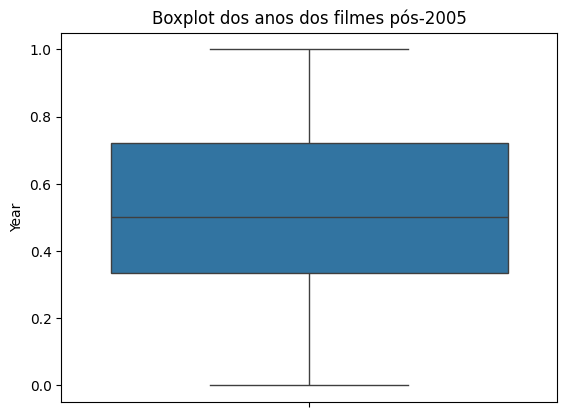

Mediana dos anos: 2014.0
Média dos anos: 2014.1994382022472
Q1: 2011.0
Q2: 2014.0
Q3: 2018.0
Q4: 2023.0
Amplitude: 18 anos
Variância: 21.957295458142113
Desvio padrão: 4.685861229074343



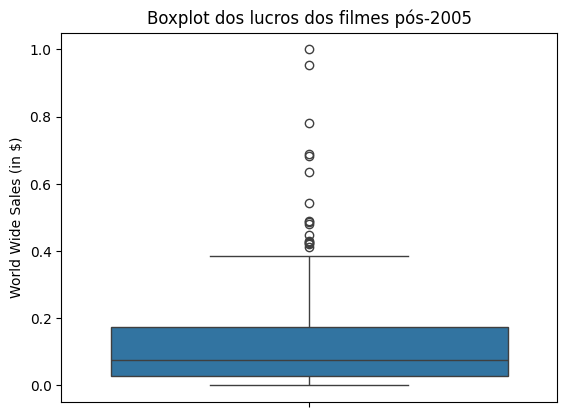

Mediana das vendas mundiais: 386140292.0
Média das vendas mundiais: 515166217.0
Q1: 253329813.75
Q2: 386140292.0
Q3: 657884011.25
Q4: 2923706026.0
Amplitude: 2743737153
Variância: 1.48368667414363e+17
Desvio padrão: 385186535.86848414


In [8]:
df_normalizado_pos = df_action_pos.copy()
print("Filmes de ação antes de 2005:", len(df_action_pos))

df_normalizado_pos["Year"] = (
    (df_action_pos["Year"] - df_action_pos["Year"].min()) /
    (df_action_pos["Year"].max() - df_action_pos["Year"].min())
)

df_normalizado_pos["World Wide Sales (in $)"] = (
    (df_action_pos["World Wide Sales (in $)"] - df_action_pos["World Wide Sales (in $)"].min()) /
    (df_action_pos["World Wide Sales (in $)"].max() - df_action_pos["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pos['Year'])
plt.title("Boxplot dos anos dos filmes pós-2005")
plt.show()

print(f"Mediana dos anos: {df_action_pos['Year'].median()}\nMédia dos anos: {df_action_pos['Year'].mean()}")
print(f"Q1: {df_action_pos['Year'].quantile(.25)}\nQ2: {df_action_pos['Year'].quantile(.50)}\nQ3: {df_action_pos['Year'].quantile(.75)}\nQ4: {df_action_pos['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action_pos['Year'].max() - df_action_pos['Year'].min()} anos")
print(f"Variância: {df_action_pos['Year'].var()}")
print(f"Desvio padrão: {df_action_pos['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pos['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes pós-2005")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action_pos['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action_pos['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action_pos['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action_pos['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action_pos['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action_pos['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action_pos['World Wide Sales (in $)'].max() - df_action_pos['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action_pos['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action_pos['World Wide Sales (in $)'].std()}")

## Análise do Período: Pós-2005
### Distribuição dos Anos de Lançamento
O grupo pós-2005 representa a grande maioria da nossa base, com 356 filmes. Ao contrário do período anterior, a distribuição temporal aqui é altamente simétrica, sem outliers, com a média (2014,2) e a mediana (2014) praticamente idênticas. Notamos também uma dispersão menor: 50% dos filmes estão espremidos em uma janela de apenas 7 anos (entre 2011 e 2018), evidenciando o grande "boom" no volume de produções de ação na última década.

### Faturamento Mundial (World Wide Sales)
O salto financeiro entre as épocas é notável. O grupo pós-2005 apresenta mediana de aproximadamente US$ 386,1 milhões e média de US$ 515,2 milhões — ambas significativamente superiores às do grupo pré-2005. O boxplot continua indicando forte assimetria à direita, mas com uma variabilidade e uma quantidade de outliers muito maiores. Isso sugere um mercado atual extremamente heterogêneo: o piso de faturamento subiu, mas o "teto" de arrecadação explodiu, marcando a era de coexistência entre filmes de desempenho mediano e os "mega blockbusters" bilionários.

### Correlação (Ano vs. Faturamento)
A Correlação de Spearman para este grupo resultou em 0,0936, com um p-valor de 0,0779. Embora esse p-valor esteja mais próximo do limite de aceitação do que no período anterior, ele ainda é superior a 0,05 (5%). Portanto, não há evidência estatística suficiente para afirmar a existência de uma relação monotônica. A conclusão final é clara: embora o mercado como um todo (pós-2005) seja muito mais rico que o passado (pré-2005), o simples avanço de um ano para o outro dentro da era moderna não é o fator que garante o aumento do faturamento de um filme.

## Conclusão Final
Após o pré-processamento minucioso e a segmentação temporal dos filmes de ação (Pré-2005 vs. Pós-2005), a análise exploratória nos permite responder à nossa pergunta de pesquisa de forma afirmativa: houve, de fato, uma mudança significativa e um **aumento expressivo no desempenho comercial dos filmes de ação** na era mais recente.

A comparação das medidas de resumo evidencia essa evolução: a mediana de arrecadação saltou de aproximadamente US$ 294 milhões (pré-2005) para US$ 386 milhões (pós-2005). Além da mediana, observamos um salto contundente na média, no terceiro quartil e primeiro quartil(Q3 e Q1) e no limite superior dos boxplots. Isso indica que a diferença não está restrita a casos isolados. O "piso" de arrecadação subiu e o "teto" explodiu, marcando a consolidação dos mega blockbusters bilionários.

Vale ressaltar o papel da correlação: embora os coeficientes de Spearman tenham sido positivos, eles se mostraram fracos e sem significância estatística. Isso significa que, dentro de uma mesma época, o simples avanço de um ano para o outro não dita o aumento da bilheteria. No entanto, a quebra estrutural e a mudança de patamar financeiro entre as duas eras é inegável.

### O Insight de Mercado: A "Fórmula" da Ação
O aumento simultâneo no volume de produções (de 152 filmes para 356) e o salto explosivo nas métricas financeiras de topo (Q3 e outliers superiores) sugerem uma forte adequação de produto ao mercado (product-market fit). Fica claro que os estúdios e produtores encontraram uma "fórmula" ou modelo de produção altamente rentável para o gênero. A indústria passou a apostar um volume muito maior de projetos e recursos nesse formato porque as bilheterias provam uma realidade irrefutável: esse é o tipo de entretenimento que o público global mais anseia consumir nas salas de cinema.

### Considerações Finais
Por fim, é indispensável salientar que este estudo analisa puramente os valores nominais de bilheteria fornecidos na base. Para uma modelagem econômica perfeita, estudos futuros precisariam considerar variáveis exógenas que **não** estão presentes neste dataset, tais como: o **ajuste da inflação** ao longo das décadas, a **desvalorização do dólar**, o **aumento no preço médio dos ingressos** e a expansão global do mercado exibidor (especialmente na Ásia) ao longo do século XXI.

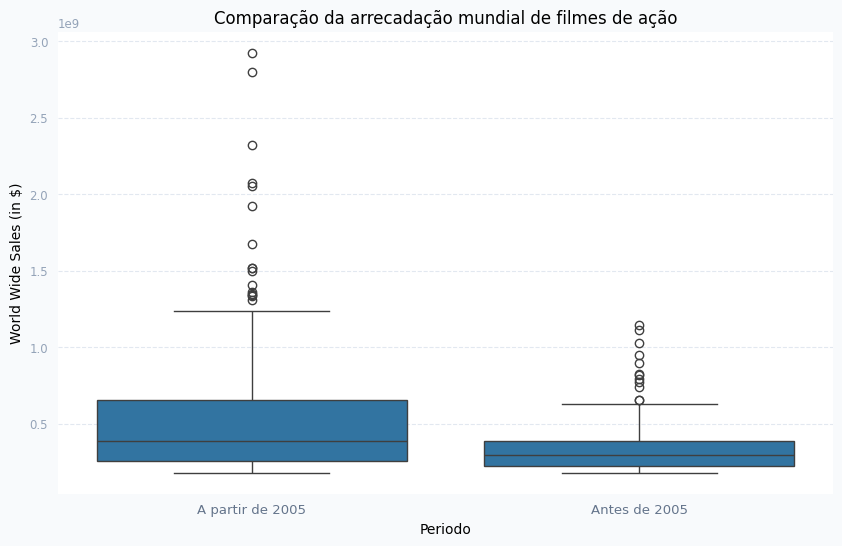

A partir de 2005
Q1: 253329813.75
Q3: 657884011.25
IQR: 404554197.5
Limite inferior: -353501482.5
Limite superior: 1264715307.5
----------------------------------------
Antes de 2005
Q1: 222569299.25
Q3: 390067955.25
IQR: 167498656.0
Limite inferior: -28678684.75
Limite superior: 641315939.25
----------------------------------------


In [25]:
df_action["Periodo"] = df_action["Year"].apply(lambda x: "Antes de 2005" if x < 2005 else "A partir de 2005")

plt.figure(figsize=(10,6))
sns.boxplot(data=df_action, x="Periodo", y="World Wide Sales (in $)")
plt.title("Comparação da arrecadação mundial de filmes de ação")
plt.ylabel("World Wide Sales (in $)")
plt.show()
grupos = df_action.groupby("Periodo")["World Wide Sales (in $)"]

for periodo, valores in grupos:
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    print(f"{periodo}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print("-" * 40)

## Gráfico Comparativo: A Evolução Financeira do Cinema de Ação
O boxplot comparativo acima consolida visualmente a principal conclusão deste estudo: a indústria de filmes de ação experimentou uma expressiva expansão financeira a partir de 2005. Analisando as métricas e a distribuição gráfica, destacam-se os seguintes fenômenos:

### O Teto do Passado é o Padrão Atual: 
Uma das observações mais contundentes reveladas por este gráfico é que o limite superior de faturamento do período Pré-2005 (aproximadamente US$ 641 milhões) se equipara à linha do terceiro quartil (Q3) do período Pós-2005 (aproximadamente US$ 657 milhões). Ou seja, o que antes era considerado o limite máximo de sucesso "dentro do padrão" (antes de virar um outlier), hoje representa apenas a base que separa os 25% filmes mais rentáveis do resto. Esse dado isolado reforça a afirmação de que os lucros dos filmes de ação na era pós-2005 estão, sim, aumentando expressivamente, e não diminuindo.

### A Elevação do Teto Financeiro Global: 
Acompanhando esse salto, o limite superior do período mais recente dobrou, chegando a impressionantes US$ 1,26 bilhão. Isso prova que o potencial máximo de lucro da indústria escalou drasticamente.

### Maior Dispersão de Mercado (IQR): 
A caixa azul do período Pós-2005 é notavelmente mais "larga". O Intervalo Interquartil (IQR), que concentra 50% dos dados centrais, passou de US$ 167 milhões para US$ 404 milhões. Isso ilustra um mercado contemporâneo muito mais heterogêneo, acentuando a distância entre sucessos medianos e os grandes hits.

### A Era dos Mega Outliers: 
A distribuição dos pontos acima das caixas evidencia visualmente o resultado da atual "fórmula de Hollywood". O volume de outliers disparou, com a magnitude de faturamento dos mega blockbusters atingindo picos isolados que chegam a rondar a marca inédita de US$ 3 bilhões.

### Nota Técnica: 
Os limites inferiores teóricos calculados pelo boxplot resultam em valores matematicamente negativos (ex: -US$ 353 milhões e -US$ 286 milhões) devido à alta dispersão e assimetria à direita dos dados. Na prática, como validado na etapa de pré-processamento, não existem bilheterias negativas na base de dados analisada.

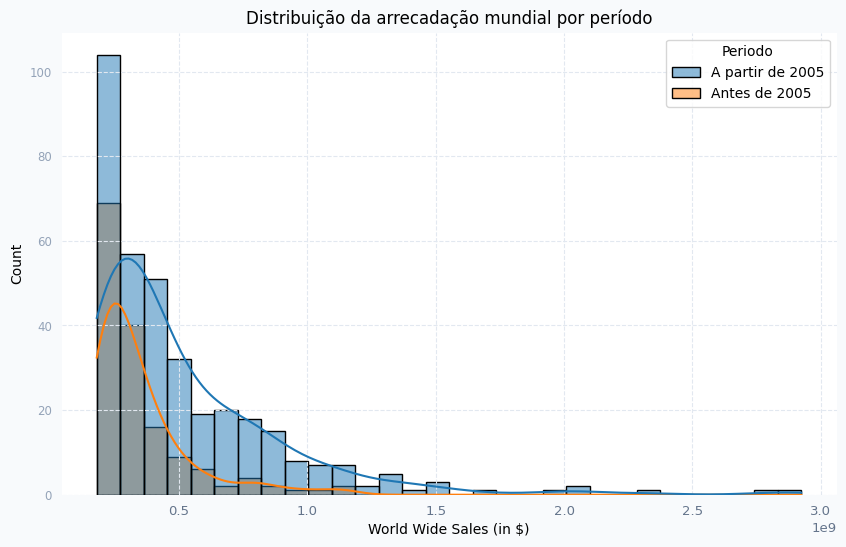

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_action, x="World Wide Sales (in $)", hue="Periodo", kde=True, bins=30)
plt.title("Distribuição da arrecadação mundial por período")
plt.show()

## Gráfico de Distribuição: A "Cauda Longa" dos Mega Blockbusters
O histograma sobreposto ilustra a distribuição de frequência da arrecadação mundial para os dois períodos analisados. Esta visualização reforça os achados anteriores sob a perspectiva de densidade e volume, permitindo destacar três pontos cruciais do mercado de filmes de ação:

### Assimetria à Direita em Ambas as Eras: 
As curvas de densidade (linhas contínuas azul e laranja) confirmam que, independente do período, a distribuição de lucros em Hollywood é fortemente assimétrica à direita. Isso significa que a grande massa de filmes (os picos altos à esquerda) possui arrecadações "comuns", enquanto o sucesso extremo é reservado a uma minoria (a cauda que se estende para a direita).

### Aumento no Volume de Produção: 
O pico muito mais elevado das barras e da curva azul reflete o "boom" na quantidade de filmes de ação produzidos a partir de 2005 (356 filmes contra 152 do período anterior). A base da pirâmide da indústria cresceu significativamente.

### A Expansão da "Cauda Longa" (The Long Tail): 
Enquanto a curva laranja (Antes de 2005) achata e perde força de forma relativamente precoce, a curva azul (A partir de 2005) cria uma "cauda longa" espessa que se arrasta por toda a extensão do gráfico, alcançando a marca dos US$ 3 bilhões. Isso prova visualmente que a era moderna não apenas produz mais filmes, mas sustenta um ecossistema onde o teto de arrecadação foi completamente redefinido.

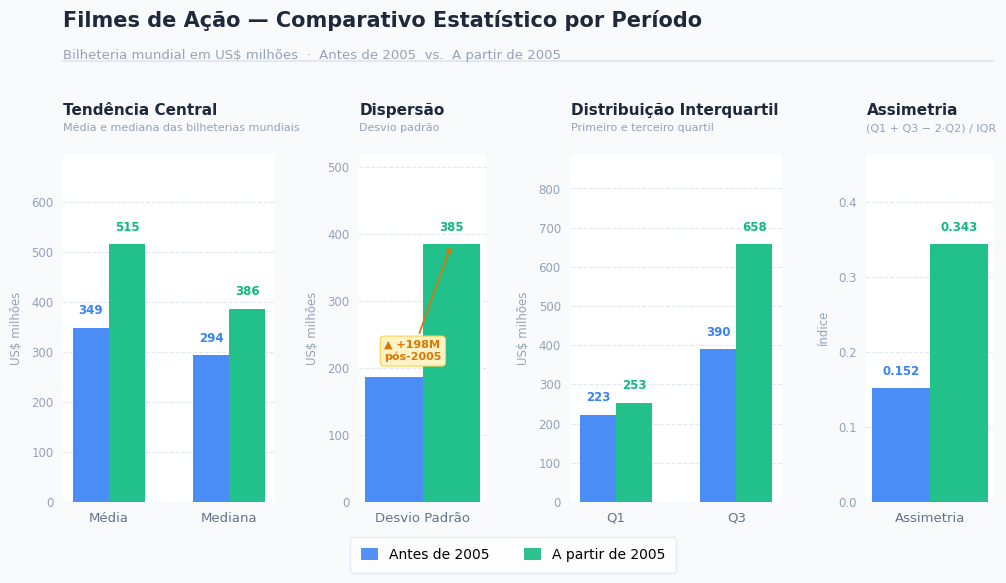

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


C_PRE  = '#3B82F6'
C_POS  = '#10B981'
C_PRE2 = '#BFDBFE'
C_POS2 = '#A7F3D0'
DARK   = '#1E293B'
MID    = '#64748B'
LIGHT  = '#94A3B8'
BG     = '#F8FAFC'
PANEL  = '#FFFFFF'
GRID   = '#E2E8F0'

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     PANEL,
    'figure.facecolor':   BG,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         GRID,
    'grid.linewidth':     0.8,
    'grid.linestyle':     '--',
    'xtick.bottom':       False,
    'ytick.left':         False,
    'xtick.color':        MID,
    'ytick.color':        LIGHT,
    'xtick.labelsize':    9.5,
    'ytick.labelsize':    8.5,
})


def calc_stats(serie):
    q1  = serie.quantile(0.25)
    q2  = serie.quantile(0.50)
    q3  = serie.quantile(0.75)
    iqr = q3 - q1
    return {
        'Média':       serie.mean()        / 1e6,
        'Mediana':     q2                  / 1e6,
        'Desvio Pad.': serie.std()         / 1e6,
        'Q1':          q1                  / 1e6,
        'Q3':          q3                  / 1e6,
        'Assimetria':  (q1 + q3 - 2*q2) / iqr if iqr != 0 else 0,
    }

s_pre = calc_stats(df_action_pre['World Wide Sales (in $)'])
s_pos = calc_stats(df_action_pos['World Wide Sales (in $)'])


def draw_bars(ax, xs, pre_vals, pos_vals, xlabels, ylabel='US$ milhões', fmt_float=False):
    W = 0.30
    ymax = max(abs(v) for v in pre_vals + pos_vals)
    has_neg = any(v < 0 for v in pre_vals + pos_vals)

    for i, (vp, vpo) in enumerate(zip(pre_vals, pos_vals)):
        ax.bar(xs[i] - W/2, vp,  width=W, color=C_PRE2, linewidth=0, zorder=2)
        ax.bar(xs[i] + W/2, vpo, width=W, color=C_POS2, linewidth=0, zorder=2)
        ax.bar(xs[i] - W/2, vp,  width=W, color=C_PRE,  linewidth=0, alpha=0.88, zorder=3)
        ax.bar(xs[i] + W/2, vpo, width=W, color=C_POS,  linewidth=0, alpha=0.88, zorder=3)

        off = ymax * 0.04
        label_p  = f'{vp:.3f}'  if fmt_float else f'{vp:,.0f}'
        label_po = f'{vpo:.3f}' if fmt_float else f'{vpo:,.0f}'
        va_p  = 'bottom' if vp  >= 0 else 'top'
        va_po = 'bottom' if vpo >= 0 else 'top'
        off_p  =  off if vp  >= 0 else -off
        off_po =  off if vpo >= 0 else -off
        ax.text(xs[i] - W/2, vp  + off_p,  label_p,
                ha='center', va=va_p,  fontsize=8.5, color=C_PRE, fontweight='bold')
        ax.text(xs[i] + W/2, vpo + off_po, label_po,
                ha='center', va=va_po, fontsize=8.5, color=C_POS, fontweight='bold')

    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, color=MID)
    margin = ymax * 0.35
    if has_neg:
        ax.set_ylim(-ymax - margin, ymax + margin)
        ax.axhline(0, color=GRID, linewidth=1.0, zorder=1)
    else:
        ax.set_ylim(0, ymax + margin)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    ax.set_ylabel(ylabel, fontsize=8.5, color=LIGHT, labelpad=6)

def panel_title(ax, title, subtitle):
    ax.set_title(title, fontsize=11, fontweight='bold', color=DARK,
                 pad=28, loc='left')
    ax.text(0.0, 1.06, subtitle, transform=ax.transAxes,
            fontsize=8, color=LIGHT, va='bottom')


fig, axes = plt.subplots(1, 4, figsize=(10, 6),
                          gridspec_kw={'width_ratios': [2, 1.2, 2, 1.2]})
fig.patch.set_facecolor(BG)
fig.subplots_adjust(left=0.05, right=0.98, top=0.72, bottom=0.14, wspace=0.5)


fig.text(0.05, 0.96,
         'Filmes de Ação — Comparativo Estatístico por Período',
         fontsize=15, fontweight='bold', color=DARK, va='top')
fig.text(0.05, 0.895,
         'Bilheteria mundial em US$ milhões  ·  Antes de 2005  vs.  A partir de 2005',
         fontsize=9.5, color=LIGHT, va='top')
fig.add_artist(plt.Line2D([0.05, 0.98], [0.875, 0.875],
               transform=fig.transFigure, color=GRID, linewidth=1.5))


draw_bars(axes[0], np.arange(2),
          [s_pre['Média'], s_pre['Mediana']],
          [s_pos['Média'], s_pos['Mediana']],
          ['Média', 'Mediana'])
panel_title(axes[0], 'Tendência Central',
            'Média e mediana das bilheterias mundiais')

draw_bars(axes[1], np.arange(1),
          [s_pre['Desvio Pad.']],
          [s_pos['Desvio Pad.']],
          ['Desvio Padrão'])
panel_title(axes[1], 'Dispersão', 'Desvio padrão')
diff = s_pos['Desvio Pad.'] - s_pre['Desvio Pad.']
axes[1].annotate(f'▲ +{diff:,.0f}M\npós-2005',
                 xy=(0.15, s_pos['Desvio Pad.']),
                 xytext=(-0.2, s_pos['Desvio Pad.'] * 0.55),
                 fontsize=8, color='#D97706', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#D97706', lw=1.2),
                 bbox=dict(boxstyle='round,pad=0.35', facecolor='#FEF3C7',
                           edgecolor='#FCD34D', linewidth=0.8))

draw_bars(axes[2], np.arange(2),
          [s_pre['Q1'], s_pre['Q3']],
          [s_pos['Q1'], s_pos['Q3']],
          ['Q1', 'Q3'])
panel_title(axes[2], 'Distribuição Interquartil', 'Primeiro e terceiro quartil')

draw_bars(axes[3], np.arange(1),
          [s_pre['Assimetria']],
          [s_pos['Assimetria']],
          ['Assimetria'],
          ylabel='índice', fmt_float=True)
panel_title(axes[3], 'Assimetria', '(Q1 + Q3 − 2·Q2) / IQR')

p1 = mpatches.Patch(facecolor=C_PRE, alpha=0.88, label='Antes de 2005')
p2 = mpatches.Patch(facecolor=C_POS, alpha=0.88, label='A partir de 2005')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2,
           fontsize=10, frameon=True, facecolor=PANEL, edgecolor=GRID,
           bbox_to_anchor=(0.5, 0.01), handlelength=1.2, handleheight=0.9,
           borderpad=0.8, columnspacing=2.5)

plt.show()

## Painel Estatístico: Resumo Executivo da Evolução do Mercado
Este painel consolida as principais métricas descritivas do nosso estudo em um formato de fácil leitura, destrinchando a evolução financeira dos filmes de ação em quatro pilares estatísticos fundamentais:

### Tendência Central (O Crescimento Real): 
O primeiro quadro quantifica de forma clara o salto de patamar do mercado. A média de faturamento global subiu de US$ 349 milhões para US$ 515 milhões, enquanto a mediana (que é menos sensível a outliers) avançou solidamente de US$ 294 milhões para US$ 386 milhões. Esse crescimento duplo comprova que o "filme médio" de ação da era moderna se tornou consideravelmente mais lucrativo.

### Dispersão (O Aumento da Variabilidade): 
O salto do desvio padrão, marcado por um expressivo aumento de US$ 198 milhões na era Pós-2005, ilustra a nova realidade da indústria. Um mercado com maior dispersão significa que os resultados são mais elásticos: embora o teto de lucros seja incrivelmente alto, a variação de desempenho entre um filme e outro é muito mais agressiva atualmente. É um cenário de alto investimento e alta volatilidade.

### Distribuição Interquartil (A Nova Régua de Sucesso): 
Observando os quartis, notamos que o "piso" de arrecadação dos grandes lançamentos (Q1) teve um avanço modesto (de US$ 223 milhões para US$ 253 milhões). Em contrapartida, o Q3 deu um salto colossal de US$ 390 milhões para US$ 658 milhões. Isso alarga a "zona central" de lucratividade e prova que os 25% melhores filmes de hoje operam em uma escala financeira incomparável com a da década de 1990.

### Assimetria (A Força dos Mega-Hits): 
O índice de assimetria mais que dobrou, passando de 0,152 para 0,343 no período mais recente. Essa métrica traduz perfeitamente o surgimento da "fórmula de Hollywood": uma assimetria positiva muito mais acentuada indica matematicamente que um seleto grupo de filmes bilionários (os outliers extremos) está tracionando a riqueza e a média geral da indústria vigorosamente para cima.